# Hyperparameter Heston
## Architecture


In [1]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools


In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")


Cloning into '/content/fys5429'...
remote: Enumerating objects: 755, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 755 (delta 54), reused 73 (delta 28), pack-reused 654 (from 1)
Receiving objects: 100% (755/755), 63.88 MiB | 36.71 MiB/s, done.
Resolving deltas: 100% (356/356), done.
Working directory: /content/fys5429/code/notebooks


### Colab setup


In [3]:
# Pathways
data_path = Path("..") / "data" / "generated" / "hs_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")


Mounted at /content/drive
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


In [4]:
# Importing HSPINN() Class
import sys
sys.path.insert(0, "../scripts")
from hspinn import HSPINN
from train_hs import train_pinn


### Global parameters


In [5]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics for Heston
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05
v_min = 0.01
v_max = 1.0
v0 = 0.04 

# Heston specific parameters
kappa = 2.0    # mean-reversion speed
theta = 0.04   # long-run variance
xi = 0.3       # vol-of-vol
rho = -0.7     # correlation

# NN defaults (not swept here, just needed for defaults)
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 128

# Training
LEARNING_RATE = 0.001
PRINT_ROWS = 20

# PINN Loss Weights
LAMBDA_PDE = 20.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0

# Sweep values
LAYERS_VALUES     = [2, 3, 4]
NEURONS_VALUES    = [64, 128, 256]
ACTIVATION_VALUES = ['softplus', 'tanh']
SWEEP_EPOCHS      = 5000


Using device: cuda


In [6]:
# Check if data exists
if not data_path.exists():
    raise FileNotFoundError(f"Collocation data not found at {data_path}. Please run generate_hs.ipynb first.")
else:
    df_all = pd.read_parquet(data_path)
    print(f"Loaded existing data from {data_path} (S_max={df_all['S'].max():.0f})")

# Extract tensors for Heston (S, v, tau)
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    v_tensor = torch.tensor(df_subset['v'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, v_tensor, tau_tensor

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, v_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, v_ic, tau_ic = extract_tensors(df_ic)

# Combine all boundary condition points (S_lower, S_upper, v_lower, v_upper)
df_bc = df_all[df_all['point_type'].str.startswith('boundary')]
S_bc, v_bc, tau_bc = extract_tensors(df_bc)

print(f"Interior points: {len(S_in)}")
print(f"IC points:       {len(S_ic)}")
print(f"BC points:       {len(S_bc)}")


Loaded existing data from ../data/generated/hs_collocation.parquet (S_max=300)
Interior points: 10000
IC points:       2000
BC points:       1000


In [7]:
sweep_results = []
start_time = time.time()
combos = list(itertools.product(LAYERS_VALUES, NEURONS_VALUES, ACTIVATION_VALUES))
total_runs = len(combos)

header = f"{'#':>3} | {'Layers':>6} {'Neurons':>7} {'Act':>8} | {'PDE Loss':>12} {'IC Loss':>12} {'BC Loss':>12} | {'Time':>6} {'ETA':>8}"
print(header)
print("─" * len(header))

for i, (layers, neurons, act) in enumerate(combos):
    run_start = time.time()
    result = train_pinn(S_in, v_in, tau_in, 
                        S_ic, v_ic, tau_ic, 
                        S_bc, v_bc, tau_bc,
                        r, K, kappa, theta, xi, rho, 
                        device,
                        LAMBDA_PDE, LAMBDA_IC, LAMBDA_BC, SWEEP_EPOCHS,
                        lr=LEARNING_RATE, hidden_layers=layers, neurons=neurons, activation=act)

    result['layers'] = layers
    result['neurons'] = neurons
    result['activation'] = act
    sweep_results.append(result)

    run_sec = time.time() - run_start
    total_elapsed = time.time() - start_time
    eta = (total_elapsed / (i + 1)) * (total_runs - i - 1)

    print(f"{i+1:>3} | {layers:>6} {neurons:>7} {act:>8} | "
          f"{result['final_pde']:>12.6f} {result['final_ic']:>12.6f} {result['final_bc']:>12.6f} | "
          f"{run_sec:>5.0f}s {eta:>6.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")


  # | Layers Neurons      Act |     PDE Loss      IC Loss      BC Loss |   Time      ETA
────────────────────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  1 |      2      64 softplus |    27.499100   255.823044   647.835144 |    93s   1587s
  2 |      2      64     tanh |    11.461095   480.404205   275.190002 |    72s   1322s
  3 |      2     128 softplus |    19.656284   258.864288   579.585999 |   157s   1610s
  4 |      2     128     tanh |     6.618063   193.775375   291.221252 |   116s   1533s
  5 |      2     256 softplus |    21.919678   273.435089   668.080994 |   350s   2049s
  6 |      2     256     tanh |     4.770185    96.704048   296.229462 |   272s   2120s
  7 |      3      64 softplus |    25.863712   227.472275   559.007751 |   103s   1828s
  8 |      3      64     tanh |     7.331121   776.750183   188.210983 |    85s   1560s
  9 |      3     128 softplus |    24.634224   272.883789   620.902283 |   217s   1466s
 10 |      3     128     tanh |     5.676363   397.350281   218.331650 |   159s   1300s
 11 |      3     256 softplus |    20.554968   233.126114   574.158752 |   491s   1347s
 12 |      3     256     tanh | 

In [8]:
df_sweep = pd.DataFrame([{
    'layers': r['layers'],
    'neurons': r['neurons'],
    'activation': r['activation'],
    'pde_loss': r['final_pde'],
    'ic_loss': r['final_ic'],
    'bc_loss': r['final_bc'],
    'total_loss': r['final_total'],
} for r in sweep_results])

df_sweep = df_sweep.sort_values('pde_loss')
print(df_sweep.to_string(index=False))


 layers  neurons activation  pde_loss    ic_loss    bc_loss   total_loss
      4      256       tanh  3.950807 208.861389 223.321945  3284.239746
      3      256       tanh  4.139890 171.130722 249.616104  3042.185547
      4      128       tanh  4.281405 550.312256 182.257645  6500.038574
      2      256       tanh  4.770185  96.704048 296.229462  2543.591309
      3      128       tanh  5.676363 397.350281 218.331650  5178.688477
      2      128       tanh  6.618063 193.775375 291.221252  3526.221191
      3       64       tanh  7.331121 776.750183 188.210983  8855.179688
      4       64       tanh 11.380599 991.462036 213.153671 11208.000977
      2       64       tanh 11.461095 480.404205 275.190002  6409.213867
      4      256   softplus 16.303411 225.840515 530.820801  5238.577637
      2      128   softplus 19.656284 258.864288 579.585999  5879.698242
      4      128   softplus 19.913080 250.854172 599.299744  5903.301758
      3      256   softplus 20.554968 233.126114 57

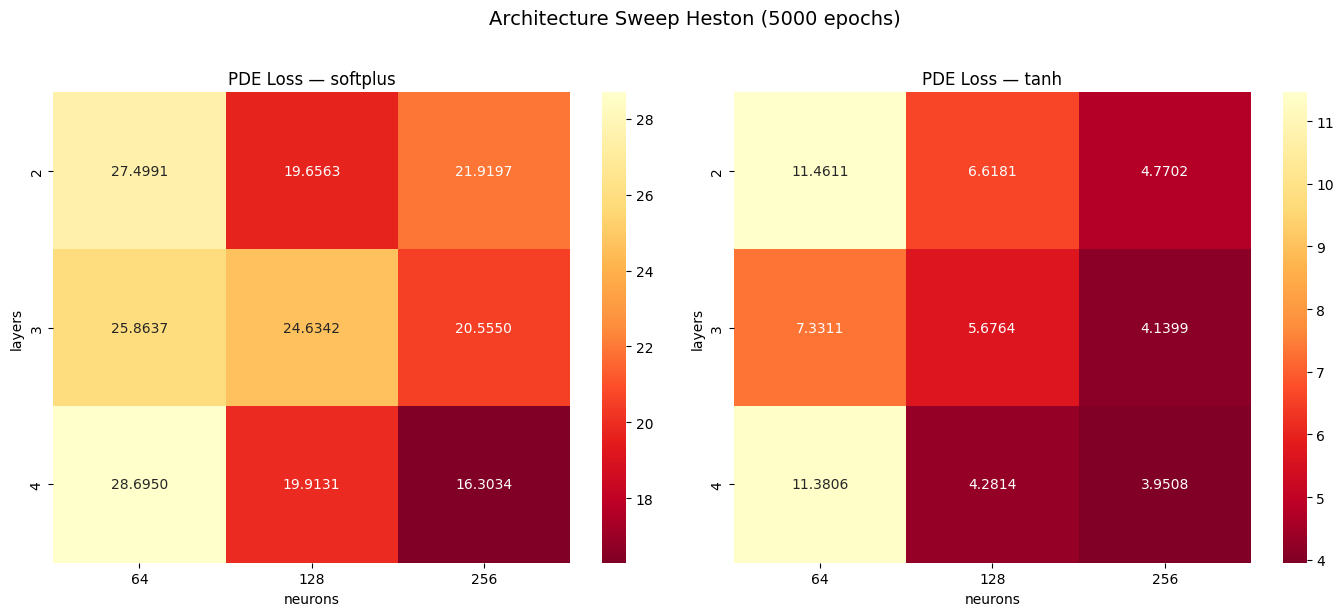

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for idx, act in enumerate(ACTIVATION_VALUES):
    df_act = df_sweep[df_sweep['activation'] == act]
    pivot = df_act.pivot_table(index='layers', columns='neurons', values='pde_loss')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=axes[idx])
    axes[idx].set_title(f'PDE Loss — {act}')

plt.suptitle(f'Architecture Sweep Heston ({SWEEP_EPOCHS} epochs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(out_dir / "hyper_hs_arch_heatmap.pdf", bbox_inches="tight")
plt.show()
